# 46. Adaptive local-residual diagnostic (`kdtree_local_residuals`)

**Objectives:**
- Compare an observed point cloud against a weighted "expected" point cloud in a 2D coordinate
  pair (`s12`, `s13`) with `kdtree_local_residuals`.
- Plot the resulting per-point Pearson pulls as a scatter colored by pull value.
- Show a deliberate model mismatch produces a visible pull pattern, and that pulls stay small
  when the two populations actually agree.

`kdtree_local_residuals` is a physics-agnostic diagnostic (`dalitzplotfitter.goodness_of_fit`):
for every observed point, a radius is set from its `k`-th nearest *expected* neighbor, and the
observed vs. weighted-expected counts inside that ball are compared with a Pearson pull. Run
cells in order in a fresh kernel.


In [1]:
from dalitzplotfitter import enable_x64
enable_x64()  # Must precede numerical work: amplitudes use complex128.

import numpy as np
import matplotlib.pyplot as plt

from dalitzplotfitter import (
    DecayChannel, DecayModel, NonResonant, Parameter, RealImag, Resonance,
    generate_toy, kdtree_local_residuals,
)

## 1. Model, toy data, and a phase-space reference sample

The rho(770) + non-resonant model used elsewhere in this course. `observed` is a toy sample drawn
from the truth; `expected_sample` is a uniform-in-phase-space sample later reweighted to the
fitted density (`generate_phase_space` produces an integration-weighted, not density-weighted,
sample -- see `docs/mc_integration.md`).

In [2]:
channel = DecayChannel("D+", ("pi-", "pi+", "pi+"))
x = Parameter.coefficient("NR.x", 0.55, owner="NR", bounds=(-2, 2), step=0.02)
y = Parameter.coefficient("NR.y", 0.30, owner="NR", bounds=(-2, 2), step=0.02)
components = [
    Resonance("rho", (0, 1), RealImag(1, 0), mass=0.7753, width=0.1491, spin=1),
    NonResonant(RealImag(x, y), name="NR"),
]
model = DecayModel(
    channel, components, normalization_method="square-dalitz",
    normalization_resolution=60, normalization_pair=(0, 1),
)
truth = {p.name: p.value for p in model.parameters}

observed = generate_toy(model, 400, parameters=truth, seed=5, inverse_resolution=256)
expected_sample = model.generate_phase_space(4000, seed=6)

observed_points = np.column_stack([np.asarray(observed.s12), np.asarray(observed.s13)])
expected_points = np.column_stack([np.asarray(expected_sample.s12), np.asarray(expected_sample.s13)])

## 2. Agreement case: reweight to the correct (truth) density

`expected_weights` combine the sample's own integration weight with the fitted intensity
`|A|^2`, so `expected_points` reweighted this way approximates the same density `observed` was
drawn from.

In [3]:
intensity_truth = np.asarray(model.intensity(expected_sample.as_dict(), truth))
weights_agree = np.asarray(expected_sample.weights) * intensity_truth

pulls_agree, obs_count, exp_count, radii = kdtree_local_residuals(
    observed_points, expected_points, weights_agree, k=30,
)
print(f"agreement case: mean(pull)={pulls_agree.mean():.3f}  std(pull)={pulls_agree.std():.3f}")
print(f"fraction |pull|>3: {np.mean(np.abs(pulls_agree) > 3):.3f}")

agreement case: mean(pull)=0.398  std(pull)=1.240
fraction |pull|>3: 0.028


## 3. Mismatch case: reweight to a visibly different (wrong) density

Set the non-resonant coefficients to zero, removing the NR amplitude and all rho-NR interference
-- a clearly different Dalitz-plot shape from the one `observed` was actually generated from.

In [4]:
wrong_values = dict(truth)
wrong_values["NR.x"] = 0.0
wrong_values["NR.y"] = 0.0

intensity_wrong = np.asarray(model.intensity(expected_sample.as_dict(), wrong_values))
weights_mismatch = np.asarray(expected_sample.weights) * intensity_wrong

pulls_mismatch, *_ = kdtree_local_residuals(
    observed_points, expected_points, weights_mismatch, k=30,
)
print(f"mismatch case: mean(pull)={pulls_mismatch.mean():.3f}  std(pull)={pulls_mismatch.std():.3f}")
print(f"fraction |pull|>3: {np.mean(np.abs(pulls_mismatch) > 3):.3f}")
assert np.std(pulls_mismatch) > np.std(pulls_agree)

mismatch case: mean(pull)=0.898  std(pull)=2.507
fraction |pull|>3: 0.220


## 4. Plot: pulls as a colored scatter

Side by side: the mismatched reference density shows a systematic pull pattern (observed data,
drawn with the rho-NR interference, over/under-populates regions relative to the NR-free
reference); the correctly reweighted reference shows small, structureless pulls.

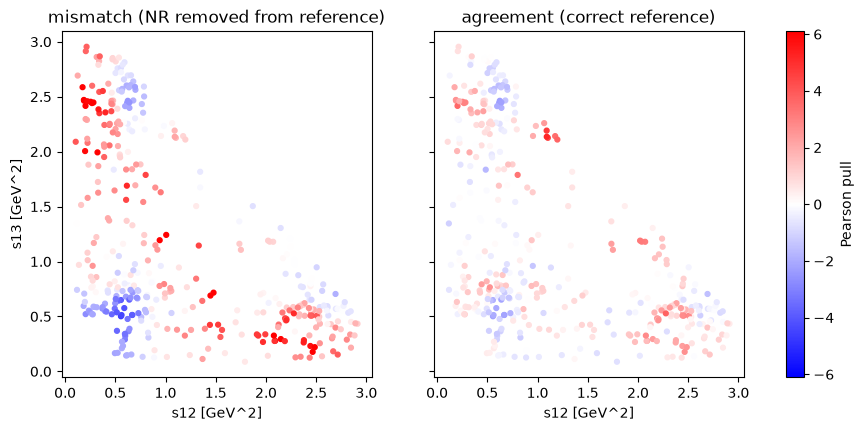

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
vmax = np.percentile(np.abs(np.concatenate([pulls_agree, pulls_mismatch])), 98)

for ax, pulls, title in (
    (axes[0], pulls_mismatch, "mismatch (NR removed from reference)"),
    (axes[1], pulls_agree, "agreement (correct reference)"),
):
    scatter = ax.scatter(
        observed_points[:, 0], observed_points[:, 1], c=pulls,
        cmap="bwr", vmin=-vmax, vmax=vmax, s=12,
    )
    ax.set_xlabel("s12 [GeV^2]")
    ax.set_title(title)
axes[0].set_ylabel("s13 [GeV^2]")
fig.colorbar(scatter, ax=axes, label="Pearson pull")
plt.show()

## Summary and exercises

1. Lower `k` (fewer neighbors per ball) and see the pulls become noisier (smaller, more variable
   local samples) even in the agreement case -- `k` trades statistical stability against spatial
   resolution.
2. Try a smaller mismatch (e.g. `NR.x`/`NR.y` shifted by only 20% from truth instead of zeroed
   out) and see the pull pattern shrink toward the agreement case.
3. Repeat in Square-Dalitz coordinates `(m', theta')` instead of `(s12, s13)` -- the function
   works in any coordinate pair, as its docstring notes.

Reference: `docs/goodness_of_fit.md`, `dalitzplotfitter.goodness_of_fit.kdtree_local_residuals`.

Return to [the course guide](TUTORIALS.md).
